# 01. Dataset Preparation and Descriptive Statistics / 'Calls (Done).xlsx'

**How to use this notebook:**
- make a copy for each dataset: `01_data_prepare_deals.ipynb`, `01_data_prepare_calls.ipynb`, etc.
- fill in the config cell in each copy and go through all the steps
- write insights and decisions directly into the markdown cells

---
Tasks:   
`Data cleaning and preparation:`
1. Remove duplicates and irrelevant columns.
2. Handle missing values appropriately.
3. Convert data types for columns such as dates and numeric
values.

`Descriptive statistics:`
1. Calculate summary statistics (mean, median, mode,
range) for numeric fields.
2. Analyze categorical fields such as quality, stage, source, and
product.

---
## 1. Imports & Setup

In [ ]:
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

sys.path.append('../src')   # helpers.py lives in src/
import helpers as h

In [2]:
# Visualization settings
sns.set_style('whitegrid')
sns.set_palette('deep')

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paths (notebook lives in notebooks/, data lives in data/)
PROJECT_ROOT = Path().resolve().parent
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'

# Create the backup folder if it doesn't exist yet
BACKUP.mkdir(parents=True, exist_ok=True)

---
## 2. Dataset Configuration for 'Calls (Done).xlsx'

Fill in `name` and `filename` **before running** the rest of the cells.

In [3]:
# ── DATASET CONFIG ──────────────────────────────────────────────────────────
# Fill in name and filename - the rest comes after preliminary analysis

dataset_config = {

    # Short dataset name (Latin letters, no spaces)
    # Used as the file name when saving the config and backups
    # Examples: 'deals', 'contacts', 'calls', 'spend'
    'name':       'calls',

    # Source file name in the data/raw/ folder
    'filename':   'Calls (Done).xlsx',
    'config_pkl': 'config_calls.pkl',
    'data_pkl':   'calls_cleaned.pkl'
}

print(f"Dataset: {dataset_config['name']}")
print(f"File:    {dataset_config['filename']}")

Dataset: calls
File:    Calls (Done).xlsx


---
## 3. Loading Data

In [4]:
# Load the dataset by filename from the config
filepath = RAW / dataset_config['filename']

# Determine format from the file extension
if filepath.suffix == '.xlsx':
    df = pd.read_excel(filepath, dtype={'Id': str, 'CONTACTID': str})
else:
    raise ValueError(f"Unsupported file format: {filepath.suffix}")

print(f"Loaded: {dataset_config['filename']}")
df_size_prev = (f"Original dataset size:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_prev)

Loaded: Calls (Done).xlsx
Original dataset size:   95_874 rows × 11 columns


---
## 4. Preliminary Analysis

Take a first look at the data - what's actually in there.  
After this section, fill in the column types in Section 5.

In [5]:
# First rows
df.head(7)

,Id,Call Start Time,Call Owner Name,CONTACTID,Call Type,Call Duration (in seconds),Call Status,Dialled Number,Outgoing Call Status,Scheduled in CRM,Tag
0,5805028000000805001,30.06.2023 08:43,John Doe,NaN,Inbound,171.00,Received,NaN,NaN,NaN,NaN
1,5805028000000768006,30.06.2023 08:46,John Doe,NaN,Outbound,28.00,Attended Dialled,NaN,Completed,0.00,NaN
2,5805028000000764027,30.06.2023 08:59,John Doe,NaN,Outbound,24.00,Attended Dialled,NaN,Completed,0.00,NaN
3,5805028000000787003,30.06.2023 09:20,John Doe,5805028000000645014,Outbound,6.00,Attended Dialled,NaN,Completed,0.00,NaN
4,5805028000000768019,30.06.2023 09:30,John Doe,5805028000000645014,Outbound,11.00,Attended Dialled,NaN,Completed,0.00,NaN
5,5805028000000790004,30.06.2023 12:09,John Doe,5805028000000645014,Outbound,12.00,Attended Dialled,NaN,Completed,0.00,NaN
6,5805028000000773022,30.06.2023 14:24,John Doe,5805028000000645014,Outbound,4.00,Attended Dialled,NaN,Completed,0.00,NaN


### Dataset Description

|Column name  | Description |   
|------------------|----------|  
| **calls_id** | Call ID |   
| **call_start_time** | Call start time |   
| **call_owner_name** | Manager who was on the call |   
| **contact_id** | ID of the contact the call was with |   
| **call_type** | Call type: |    
|     - Inbound - answered inbound call, |   
|     - Missed - missed inbound call, |   
|     - Outbound - outbound call |  
| **call_duration_in_seconds** | Call duration in seconds |   
| **call_status** | Detailed call status (many different values) |   
| **dialled_number** | Number dialled on the customer's side |   
| **outgoing_call_status** | Detailed call status (many different values) |   
| **scheduled_in_crm** | Flag for whether the call was scheduled in advance |   
| **tag** | Label a manager may have assigned to the call |

In [6]:
# Rename columns: strip whitespace and parentheses, convert to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Columns after renaming:")
print(df.columns.tolist())

Columns after renaming:
['id', 'call_start_time', 'call_owner_name', 'contactid', 'call_type', 'call_duration_in_seconds', 'call_status', 'dialled_number', 'outgoing_call_status', 'scheduled_in_crm', 'tag']


In [7]:
# Rename specific columns
df.rename(columns={'id': 'calls_id', 'contactid': 'contact_id'}, inplace=True)
print("\nFirst rows of the DataFrame after renaming the field:")
df.head(3)


First rows of the DataFrame after renaming the field:


,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,dialled_number,outgoing_call_status,scheduled_in_crm,tag
0,5805028000000805001,30.06.2023 08:43,John Doe,NaN,Inbound,171.00,Received,NaN,NaN,NaN,NaN
1,5805028000000768006,30.06.2023 08:46,John Doe,NaN,Outbound,28.00,Attended Dialled,NaN,Completed,0.00,NaN
2,5805028000000764027,30.06.2023 08:59,John Doe,NaN,Outbound,24.00,Attended Dialled,NaN,Completed,0.00,NaN


In [8]:
# Size and column dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   calls_id                  95874 non-null  object 
 1   call_start_time           95874 non-null  object 
 2   call_owner_name           95874 non-null  object 
 3   contact_id                91941 non-null  object 
 4   call_type                 95874 non-null  object 
 5   call_duration_in_seconds  95791 non-null  float64
 6   call_status               95874 non-null  object 
 7   dialled_number            0 non-null      float64
 8   outgoing_call_status      86875 non-null  object 
 9   scheduled_in_crm          86875 non-null  float64
 10  tag                       0 non-null      float64
dtypes: float64(4), object(7)
memory usage: 8.0+ MB


In [9]:
df.describe(include='all')

,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,dialled_number,outgoing_call_status,scheduled_in_crm,tag
count,95874,95874,95874,91941,95874,95791.00,95874,0.00,86875,86875.00,0.00
unique,95874,68445,33,15214,3,NaN,11,NaN,4,NaN,NaN
top,5805028000000805001,06.06.2024 15:07,Yara Edwards,5805028000003329100,Outbound,NaN,Attended Dialled,NaN,Completed,NaN,NaN
freq,1,9,9059,94,86875,NaN,70703,NaN,86792,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,164.98,NaN,NaN,NaN,0.00,NaN
std,NaN,NaN,NaN,NaN,NaN,401.41,NaN,NaN,NaN,0.04,NaN
min,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN
25%,NaN,NaN,NaN,NaN,NaN,4.00,NaN,NaN,NaN,0.00,NaN
50%,NaN,NaN,NaN,NaN,NaN,8.00,NaN,NaN,NaN,0.00,NaN
75%,NaN,NaN,NaN,NaN,NaN,98.00,NaN,NaN,NaN,0.00,NaN


In [10]:
# Summary table for numeric columns 
h.descr_df(df)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,call_duration_in_seconds,float64,95791,83,2619,0.00,4.00,164.98,8.00,98.00,7625.00,7625.00,94.00
1,dialled_number,float64,0,95874,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,scheduled_in_crm,float64,86875,8999,2,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00
3,tag,float64,0,95874,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Summary table for all columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,calls_id,object,95874,0,95874,5805028000000805001,5805028000000768006,5805028000000764027
1,call_start_time,object,95874,0,68445,30.06.2023 08:43,30.06.2023 08:46,30.06.2023 08:59
2,call_owner_name,object,95874,0,33,John Doe,John Doe,John Doe
3,contact_id,object,91941,3933,15214,NaN,NaN,NaN
4,call_type,object,95874,0,3,Inbound,Outbound,Outbound
5,call_status,object,95874,0,11,Received,Attended Dialled,Attended Dialled
6,outgoing_call_status,object,86875,8999,4,NaN,Completed,Completed


In [12]:
# Missing values - first look
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

,missing,%
tag,95874,100.00
dialled_number,95874,100.00
outgoing_call_status,8999,9.40
scheduled_in_crm,8999,9.40
contact_id,3933,4.10
call_duration_in_seconds,83,0.10


In [13]:
# Full duplicate rows - first look
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

Duplicate rows: 0


**Dataset description:** 

Our 'Calls (Done)' dataset has 95_874 observations and 11 variables.  
Columns with missing values: 'tag', 'dialled_number', 'outgoing_call_status', 'scheduled_in_crm', 'contact_id', 'call_duration_in_seconds'.  
Categorical variables such as 'call_owner_name', 'call_type', 'call_status' and 'outgoing_call_status' have the object dtype.

**Insights:** 

1) On load, column types were changed: 'Id' -> str, 'CONTACTID' -> str - to avoid precision loss.
2) Column names originally had whitespace, parentheses and uppercase letters.
3) Renamed: 'id' -> 'calls_id', 'contactid' -> 'contact_id' - consistent style.   
4) 'tag', 'dialled_number' - drop the columns (100% missing). 'outgoing_call_status' - unused column (based on the filled-in values it fully matches the statuses in 'call_status', and the latter is more detailed on scheduled-call stages).       
5) 'call_start_time' - a time field, but stored as object dtype.
6) 'call_owner_name', 'call_type', 'call_status' - convert to 'Category'.
7) 'call_duration_in_seconds' -> needs to be converted to int64.

---
## 5. Refining the Config: Column Types

Fill in the lists based on the preliminary analysis above.  
After filling them in, run the cell - the config will be saved.

In [14]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

['call_duration_in_seconds', 'dialled_number', 'scheduled_in_crm', 'tag']


In [15]:
cat_cols = list(df.select_dtypes(include='object').columns)
print(cat_cols)

['calls_id', 'call_start_time', 'call_owner_name', 'contact_id', 'call_type', 'call_status', 'outgoing_call_status']


In [16]:
bool_cols = list(df.select_dtypes(include='bool').columns)
print(bool_cols)

[]


In [17]:
date_cols = list(df.select_dtypes(include='datetime').columns)
print(date_cols)

[]


In [18]:
# Fill in the lists based on Section 4's results ONCE, then run the code and comment it out
# If a column was already loaded from a saved config, it's fine to leave as-is

dataset_config['num_cols'] = [
    # Numeric: sla, initial_amount_paid, offer_total_amount, ...
    'call_duration_in_seconds'
    # *num_cols,
]

dataset_config['cat_cols'] = [
    # Categorical: stage, source, product, quality, ...
    'call_owner_name', 'call_type', 'call_status'
     # *cat_cols,
]

dataset_config['bool_cols'] = [
    # Boolean (True/False or 0/1): e.g. scheduled_in_crm
    # '',
    *bool_cols
]

dataset_config['date_cols'] = [
    # Dates: created_time, closing_date, ...
    'call_start_time',
    # *date_cols
]

dataset_config['drop_cols'] = [
    # Columns definitely not needed for analysis
    'dialled_number', 'tag', 'outgoing_call_status', 'cheduled_in_crm'
]

# Remove empty placeholder strings from the lists
for key in ['num_cols', 'cat_cols', 'bool_cols', 'date_cols', 'drop_cols']:
    dataset_config[key] = [col for col in dataset_config[key] if col]

print("Config ready:")
print("=" * 50)
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config ready:
  name: calls
  filename: Calls (Done).xlsx
  config_pkl: config_calls.pkl
  data_pkl: calls_cleaned.pkl
  num_cols: ['call_duration_in_seconds']
  cat_cols: ['call_owner_name', 'call_type', 'call_status']
  bool_cols: []
  date_cols: ['call_start_time']
  drop_cols: ['dialled_number', 'tag', 'outgoing_call_status', 'cheduled_in_crm']


**Insights:** 

1) 'scheduled_in_crm' - 2 unique values: (0, 1) -> int - not used
2) 'call_start_time' - a time field, but stored as object dtype.
3) 'dialled_number', 'tag' - columns fully missing (100% missing data).
4) 'outgoing_call_status' - unused column

### Saving the Config and Dataset to pkl

In [19]:
# Force id -> string
# to be sure the dtype doesn't shift (needed for merges)

id_cols = ['calls_id', 'contact_id'] 

for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')
        
# Save the CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")
print(f"{'─'*60}")
print(f"ID types: { {col: df[col].dtype for col in id_cols if col in df} }")

Config saved: data\processed\config_calls.pkl
Dataset saved: data\processed\calls_cleaned.pkl
Size: 95_874 × 11
────────────────────────────────────────────────────────────
ID types: {'calls_id': string[python], 'contact_id': string[python]}


---
## 6. Converting Data Types

### Datetime Columns

In [20]:
# Convert dates
for col in dataset_config['date_cols']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True) # dayfirst=True -> European format
        print(f"  {col} -> datetime {df[col].dtype}")

  call_start_time -> datetime datetime64[ns]


In [21]:
df['call_start_time'].head(3)

0   2023-06-30 08:43:00
1   2023-06-30 08:46:00
2   2023-06-30 08:59:00
Name: call_start_time, dtype: datetime64[ns]

In [22]:
# Create a 'call_start_date' column containing only the date, format='%d.%m.%Y'
col = 'call_start_time'
df['call_start_date'] = pd.to_datetime(df[col].dt.date, format='%d.%m.%Y')
df['call_start_date'].dtype
print(f"Date range: {df['call_start_date'].min()} - {df['call_start_date'].max()}")

Date range: 2023-06-30 00:00:00 - 2024-06-21 00:00:00


### Numeric Columns

In [23]:
# Convert numeric columns
# errors='coerce' - non-numeric values become NaN
for col in dataset_config['num_cols']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"  {col} -> numeric {df[col].dtype}")

  call_duration_in_seconds -> numeric float64


In [24]:
# 'call_duration_in_seconds' -> integer type (Int64, to preserve NaN)
col = 'call_duration_in_seconds'

df[col] = df[col].astype('Int64')  # Nullable int
print(f"{col}: {df[col].dtype}")

call_duration_in_seconds: Int64


### Boolean Columns

In [25]:
# Convert boolean columns
for col in dataset_config['bool_cols']:
    if col in df.columns:
        # Skip if the column is already bool
        if df[col].dtype != bool:
            df[col] = df[col].astype(bool)
        print(f"  {col} -> bool {df[col].dtype}")

### Columns Definitely Not Needed for Analysis

In [26]:
# Drop unneeded columns
if dataset_config['drop_cols']:
    df = df.drop(columns=[c for c in dataset_config['drop_cols'] if c in df.columns])
    print(f"Dropped columns: {dataset_config['drop_cols']}")

Dropped columns: ['dialled_number', 'tag', 'outgoing_call_status', 'cheduled_in_crm']


### Categorical Columns

In [27]:
# Better to convert categorical features to category dtype
print('\nCategorical columns:')
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Unique values in\n{cat_cols}:")
print(df.select_dtypes(include=['object']).nunique(dropna=True).values)


Categorical columns:
Unique values in
['call_owner_name', 'call_type', 'call_status']:
[33  3 11]


In [28]:
threshold = np.sqrt(len(df)) # square root of the dataset size

for col in cat_cols:
    unique_count = df[col].nunique(dropna=False)
    
    if unique_count <= threshold:
        df[col] = df[col].astype('category')
        print(f"{col} -> category (unique={unique_count})")
    else:
        print(f"{col} - kept as object (unique={unique_count})")

call_owner_name -> category (unique=33)
call_type -> category (unique=3)
call_status -> category (unique=11)


In [29]:
# List of categorical columns
# Check for typos among the categories
categorical_cols  = df.select_dtypes(include=['category']).columns.tolist()

for col in categorical_cols:
    print(f"Unique values in {col}:")
    display(df[col].value_counts(dropna=False).sort_index()) # also sort by value (alphabetically)
    print("-" * 40)

Unique values in call_owner_name:


call_owner_name
Alice Johnson      1251
Amy Green          5982
Ben Hall           2947
Bob Brown            99
Cara Iverson       3300
Charlie Davis      7213
Derek James         948
Diana Evans        6857
Ethan Harris        280
Eva Kent            498
Fiona Jackson       470
George King         850
Hannah Lee          175
Ian Miller         7215
Jane Smith         3753
John Doe           2986
Julia Nelson       7446
Kevin Parker       5406
Laura Quinn           2
Mason Roberts      1166
Nina Scott         5581
Oliver Taylor        10
Paula Underwood    4580
Quincy Vincent     4384
Rachel White        441
Sam Young           457
Tina Zhang            5
Ulysses Adams      6085
Victor Barnes      5439
Wendy Clark         162
Xander Dean         304
Yara Edwards       9059
Zachary Foster      523
Name: count, dtype: int64

----------------------------------------
Unique values in call_type:


call_type
Inbound      3078
Missed       5921
Outbound    86875
Name: count, dtype: int64

----------------------------------------
Unique values in call_status:


call_status
Attended Dialled              70703
Cancelled                        20
Missed                         5922
Overdue                          60
Received                       3077
Scheduled                         3
Scheduled Attended               14
Scheduled Attended Delay         22
Scheduled Unattended              6
Scheduled Unattended Delay       17
Unattended Dialled            16030
Name: count, dtype: int64

----------------------------------------


### Final Column Types

In [30]:
print("Config updated:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Config updated:
  name: calls
  filename: Calls (Done).xlsx
  config_pkl: config_calls.pkl
  data_pkl: calls_cleaned.pkl
  num_cols: ['call_duration_in_seconds']
  cat_cols: ['call_owner_name', 'call_type', 'call_status']
  bool_cols: []
  date_cols: ['call_start_time']
  drop_cols: ['dialled_number', 'tag', 'outgoing_call_status', 'cheduled_in_crm']


In [31]:
print(f"\nFinal column types:")
print(df.dtypes)


Final column types:
calls_id                    string[python]
call_start_time             datetime64[ns]
call_owner_name                   category
contact_id                  string[python]
call_type                         category
call_duration_in_seconds             Int64
call_status                       category
scheduled_in_crm                   float64
call_start_date             datetime64[ns]
dtype: object


**Insights:** 

1) Categorical features are better as category dtype. Their count meets the categorical criterion (number of unique values < the square root of the dataset size (309)), so all can be converted to 'category'.
2) Numeric/integer: 'call_duration_in_seconds' -> int64 (was float64, since an explicit int is more intuitive and familiar here).
3) 'scheduled_in_crm' - 2 unique values: (0, 1) - converted to int

---
## 7. Duplicates

### Full Duplicates

In [32]:
# Full duplicate rows
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")

if n_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

Duplicate rows: 0


### Duplicates by Key

In [33]:
# List of dataset fields
print(df.columns.tolist())

['calls_id', 'call_start_time', 'call_owner_name', 'contact_id', 'call_type', 'call_duration_in_seconds', 'call_status', 'scheduled_in_crm', 'call_start_date']


In [34]:
# Build a composite key column: excluding 'calls_id' (to avoid an ID-based deadlock), using ['call_duration_in_seconds' + sorted(dup_key_no_id)] -> identify duplicates by the rest of
# the matching fields: same manager / same time / other matching attributes ... + ['call_duration_in_seconds' + sorted(dup_key_no_id)]

# 1. Duplicates by key (excluding 'calls_id')
print("=== 1: Duplicates by key (excluding 'calls_id') ===")
# Key
cols_full = ['call_start_time', 'call_owner_name', 'contact_id', 'call_type', 
             'call_duration_in_seconds', 'call_status', 'scheduled_in_crm']

df['dup_key_no_id'] = df[cols_full].astype(str).agg('_'.join, axis=1)
n_before_full = len(df)

# Filter rows where the key appears more than once
duplicates = df[df.dup_key_no_id.duplicated(keep=False)]

# Sort by key
duplicates = duplicates.sort_values('dup_key_no_id')

duplicates

=== 1: Duplicates by key (excluding 'calls_id') ===


,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,scheduled_in_crm,call_start_date,dup_key_no_id
34,5805028000001140014,2023-07-06 17:15:00,Alice Johnson,5805028000001129001,Outbound,0,Unattended Dialled,0.00,2023-07-06,2023-07-06 17:15:00_Alice Johnson_580502800000...
35,5805028000001167001,2023-07-06 17:15:00,Alice Johnson,5805028000001129001,Outbound,0,Unattended Dialled,0.00,2023-07-06,2023-07-06 17:15:00_Alice Johnson_580502800000...
101,5805028000001372054,2023-07-08 16:43:00,John Doe,<NA>,Missed,0,Missed,NaN,2023-07-08,2023-07-08 16:43:00_John Doe_<NA>_Missed_0_Mis...
102,5805028000001348077,2023-07-08 16:43:00,John Doe,<NA>,Missed,0,Missed,NaN,2023-07-08,2023-07-08 16:43:00_John Doe_<NA>_Missed_0_Mis...
254,5805028000001568042,2023-07-12 19:23:00,Jane Smith,5805028000001552025,Outbound,0,Unattended Dialled,0.00,2023-07-12,2023-07-12 19:23:00_Jane Smith_580502800000155...
...,...,...,...,...,...,...,...,...,...,...
95804,5805028000056832311,2024-06-21 14:17:00,Yara Edwards,<NA>,Outbound,8,Attended Dialled,0.00,2024-06-21,2024-06-21 14:17:00_Yara Edwards_<NA>_Outbound...
95833,5805028000056845313,2024-06-21 14:47:00,Ulysses Adams,5805028000026041053,Outbound,0,Unattended Dialled,0.00,2024-06-21,2024-06-21 14:47:00_Ulysses Adams_580502800002...
95834,5805028000056873560,2024-06-21 14:47:00,Ulysses Adams,5805028000026041053,Outbound,0,Unattended Dialled,0.00,2024-06-21,2024-06-21 14:47:00_Ulysses Adams_580502800002...
95838,5805028000056834447,2024-06-21 14:55:00,John Doe,<NA>,Missed,0,Missed,NaN,2024-06-21,2024-06-21 14:55:00_John Doe_<NA>_Missed_0_Mis...


In [35]:
# Drop duplicates
df = df.drop_duplicates(subset='dup_key_no_id', keep='first').reset_index(drop=True)
print(f"Duplicates removed (excluding calls_id): {n_before_full - len(df)}")

Duplicates removed (excluding calls_id): 3257


In [36]:
df.shape

(92617, 10)

In [37]:
# Quick sanity check on a known example, where different call attempts or different stages of one interaction
# survived the key-based cleanup:   
# 558 sec = a full conversation: Outbound / Attended Dialled   
# 2 sec = failed/dropped call: Outbound / Attended Dialled   
# 0 sec = unanswered call: Outbound / Unattended Dialled   	
# These should remain for analyzing call-handling load, connect rate, and stage-by-stage conversion.   

filtered = df[(df['call_start_time'] == '30.07.2023 15:26') & (df['call_owner_name'] == 'Alice Johnson')].sort_values('call_duration_in_seconds', ascending=False)
print(f"Row count: {len(filtered):_}")

# We can inspect these rows   
filtered

Row count: 3


,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,scheduled_in_crm,call_start_date,dup_key_no_id
1833,5805028000003431499,2023-07-30 15:26:00,Alice Johnson,5805028000003473051,Outbound,558,Attended Dialled,0.00,2023-07-30,2023-07-30 15:26:00_Alice Johnson_580502800000...
1831,5805028000003428316,2023-07-30 15:26:00,Alice Johnson,<NA>,Outbound,2,Attended Dialled,0.00,2023-07-30,2023-07-30 15:26:00_Alice Johnson_<NA>_Outboun...
1832,5805028000003466500,2023-07-30 15:26:00,Alice Johnson,5805028000003461074,Outbound,0,Unattended Dialled,0.00,2023-07-30,2023-07-30 15:26:00_Alice Johnson_580502800000...


In [38]:
# Assign a priority to statuses: 1) 'Received' 2) 'Attended Dialled', ... - i.e. calls that actually connected
# + by call duration
print("\n=== 2: Priority by status + duration ===")

# df['dup_key'] = df[cols_full].astype(str).agg('_'.join, axis=1)

# Status priority
status_priority = {
    'Received': 3, # 1st place
    'Attended Dialled': 2, # 2nd place
    'Dialled': 1,
    'Missed': 1,
    'No Answer': 1, 
    'Busy': 1,
    'Cancelled': 0,
    'Failed': 0
}

df['status_priority'] = df['call_status'].map(status_priority).fillna(0)

# Sort: status (descending) -> duration (descending)
df_sorted = df.sort_values(['dup_key_no_id', 'status_priority', 'call_duration_in_seconds'], ascending=[True, True, True])


=== 2: Priority by status + duration ===


In [39]:
df_sorted

,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,scheduled_in_crm,call_start_date,dup_key_no_id,status_priority
0,5805028000000805001,2023-06-30 08:43:00,John Doe,<NA>,Inbound,171,Received,NaN,2023-06-30,2023-06-30 08:43:00_John Doe_<NA>_Inbound_171_...,3.00
1,5805028000000768006,2023-06-30 08:46:00,John Doe,<NA>,Outbound,28,Attended Dialled,0.00,2023-06-30,2023-06-30 08:46:00_John Doe_<NA>_Outbound_28_...,2.00
2,5805028000000764027,2023-06-30 08:59:00,John Doe,<NA>,Outbound,24,Attended Dialled,0.00,2023-06-30,2023-06-30 08:59:00_John Doe_<NA>_Outbound_24_...,2.00
3,5805028000000787003,2023-06-30 09:20:00,John Doe,5805028000000645014,Outbound,6,Attended Dialled,0.00,2023-06-30,2023-06-30 09:20:00_John Doe_58050280000006450...,2.00
4,5805028000000768019,2023-06-30 09:30:00,John Doe,5805028000000645014,Outbound,11,Attended Dialled,0.00,2023-06-30,2023-06-30 09:30:00_John Doe_58050280000006450...,2.00
...,...,...,...,...,...,...,...,...,...,...,...
92612,5805028000056889515,2024-06-21 15:30:00,Ulysses Adams,5805028000056564231,Outbound,6,Attended Dialled,0.00,2024-06-21,2024-06-21 15:30:00_Ulysses Adams_580502800005...,2.00
92613,5805028000056875317,2024-06-21 15:30:00,Victor Barnes,5805028000054867023,Outbound,8,Attended Dialled,0.00,2024-06-21,2024-06-21 15:30:00_Victor Barnes_580502800005...,2.00
92615,5805028000056893619,2024-06-21 15:30:00,Victor Barnes,5805028000056839048,Outbound,0,Unattended Dialled,0.00,2024-06-21,2024-06-21 15:30:00_Victor Barnes_580502800005...,0.00
92611,5805028000056912329,2024-06-21 15:30:00,Victor Barnes,<NA>,Outbound,<NA>,Scheduled,1.00,2024-06-21,2024-06-21 15:30:00_Victor Barnes_<NA>_Outboun...,0.00


In [40]:
del df['dup_key_no_id']

In [41]:
# Successful calls
print("\nSuccessful: connected with duration > 0 sec + status 'Received', 'Attended Dialled':") 
df['success_call'] = (df['call_duration_in_seconds'] > 0) & (df['status_priority'].isin([3, 2]))

success_call = df['success_call'].value_counts()
success_call_pct = (success_call / len(df) * 100).round(1)

success_call_df = pd.DataFrame({'successful': success_call, '%': success_call_pct})
display(success_call_df)


Successful: connected with duration > 0 sec + status 'Received', 'Attended Dialled':


,successful,%
success_call,,
True,72592,78.40
False,20025,21.60


**Decision on duplicates:**     

No full duplicate rows were found on the first pass. 
But found:   
Key-based iteration (`excluding id`) -> full match on the remaining fields and time (down to the second):   
    Duplicates: 3_257 
Total unique calls: 92_617   
So we kept: different call attempts or different stages of one interaction, for further analysis:  
   * Connect-rate efficiency analysis
   * How many with status 'Received' / 'Attended Dialled' -> converted into a deal
   * Manager workload (all attempts)
   * Time series across all interactions   
   
**Possible causes of duplication:**   
* Data replication: a script or integration created multiple records for the same event, especially where telephony, CRM and other sources are linked.  
* Duplication across CRM entities: the same call may appear on a deal, a contact, and other related records.   
* Webhooks/integrations: every "call ended" event -> multiple API requests -> multiple records.

**Successful calls** - 78.4% (72_592):   
Connected with duration > 0 sec + status 'Received', 'Attended Dialled' (priority: 3 and 2).

---
## 8. Missing Values

In [42]:
# Final view of missing values after type conversion
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_df = missing_df.query('missing > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("No missing values")
else:
    display(missing_df)

,missing,%
scheduled_in_crm,8813,9.50
contact_id,3802,4.10
call_duration_in_seconds,79,0.10


In [43]:
# Fill missing 'contact_id' with the constant 'Unknown'
df['contact_id'] = df['contact_id'].fillna('Unknown')

In [44]:
# Final view of missing values in 'call_duration_in_seconds'
col = 'call_duration_in_seconds'
na_calls = df[df[col].isnull()]
status_counts = na_calls['call_status'].value_counts()
display(status_counts)

call_status
Overdue                       57
Cancelled                     19
Scheduled                      3
Missed                         0
Attended Dialled               0
Received                       0
Scheduled Attended             0
Scheduled Attended Delay       0
Scheduled Unattended           0
Scheduled Unattended Delay     0
Unattended Dialled             0
Name: count, dtype: int64

---
Statuses among the missing values:  
Overdue                       57   
Cancelled                     19   
Scheduled                      3   

i.e. these are calls that never happened, so they can be filled with 0 sec.

In [45]:
# Fill missing values
df[col] = df[col].fillna(0)

In [46]:
num_cols = ['call_duration_in_seconds', 'scheduled_in_crm']
h.colls_stats(df, num_cols)

,Column name,Dtype,Value count,Missing (NaN),Missing %,Non-missing,Non-missing %,Unique
0,call_duration_in_seconds,Int64,92617,0,0.00,92617,100.00,2619
1,scheduled_in_crm,float64,83804,8813,9.52,83804,90.48,2


**Decision on missing values:** 

1) 'contact_id' - the call's unique identifier context (linking field) - empty values filled with 'Unknown'.
2) 'call_duration_in_seconds' - preliminary analysis showed these are calls that never happened, so filled with '0' seconds.
3) `scheduled_in_crm` - not fillable, 8813

In [47]:
# Handle missing values - fill in based on the decisions from the table above

# Example: fill numeric column with the median
# col = 'sla'
# df[col] = df[col].fillna(df[col].median())

# Example: fill categorical column with the mode
# col = 'payment_type'
# df[col] = df[col].fillna(df[col].mode()[0])

# Example: fill with a constant
# df['lost_reason'] = df['lost_reason'].fillna('not specified')

# Example: fill with the median within groups
# col = 'course_duration'
# df[col] = df[col].fillna(df.groupby(['product', 'education_type'])[col].transform('median'))
# If an entire group is empty, fall back to the global median
# df[col] = df[col].fillna(df[col].median())

# Check the result
print("Missing values after processing:")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("  No missing values")
else:
    print(remaining)

Missing values after processing:
scheduled_in_crm    8813
dtype: int64


---
## 9. Univariate Analysis - Numeric Variables

For each numeric variable:
- histogram + boxplot via `h.hist_box`
- outlier bounds via `h.iqr_outliers`

In [48]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

['call_duration_in_seconds', 'scheduled_in_crm', 'status_priority']



────────────────────────────────────────────────────────────
  call_duration_in_seconds
────────────────────────────────────────────────────────────


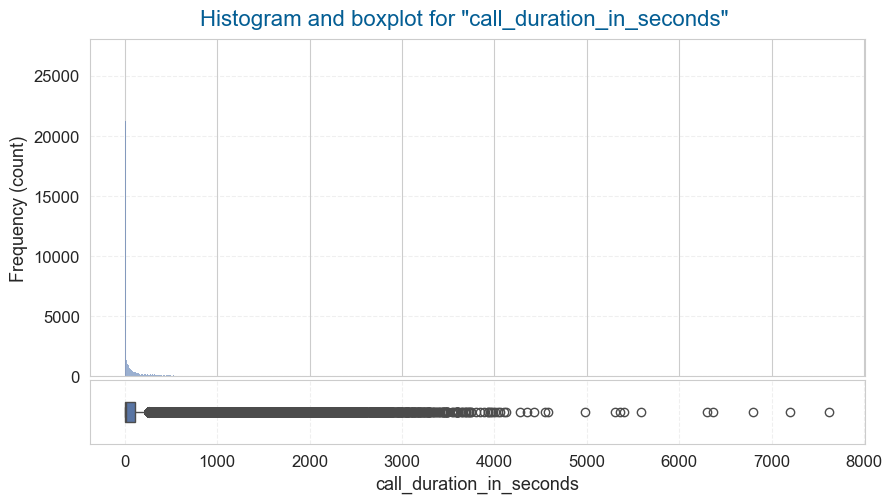

Descriptive statistics:


,0
Column name,call_duration_in_seconds
Dtype,Int64
Value count,92617
Missing (NaN),0
Unique values,2619
Min,0
Q1,4.00
Mean,170.18
Q2 Median,9.00
Q3,107.00


Whisker bounds and outliers:


,Left,Right
Outlier bounds,-150.50,261.50
Outlier count,0.00,15868.00
Outlier %,0.00,17.13


In [49]:
for col in dataset_config['num_cols']:
    if col not in df.columns:
        print(f"Column {col} not found in the dataset, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Histogram + boxplot
    h.hist_box(col, df, title=col)
    print('Descriptive statistics:')
    display(h.descr_df(df[[col]], show=False).T)

    # Table with quantiles and outlier bounds
    print('Whisker bounds and outliers:')
    h.iqr_outliers(col, df)

In [50]:
# Convert the "call_duration_in_seconds" column to an integer type, using the 'Int64' dtype which supports missing values (NaN)
df['call_duration_in_seconds'] = df['call_duration_in_seconds'].fillna(0).astype('int64')

In [51]:
h.descr_df(df[['call_duration_in_seconds']])

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,call_duration_in_seconds,int64,92617,0,2619,0,4.00,170.18,9.00,107.00,7625,7625,103.00


In [52]:
print("Duration distribution:")
print("\nCall statuses:")
print(df['call_status'].value_counts())

Duration distribution:

Call statuses:
call_status
Attended Dialled              69522
Unattended Dialled            14146
Missed                         5743
Received                       3070
Overdue                          57
Scheduled Attended Delay         20
Cancelled                        19
Scheduled Unattended Delay       17
Scheduled Attended               14
Scheduled Unattended              6
Scheduled                         3
Name: count, dtype: int64


`call_duration`: 0-107s (median 9s), 17% outliers (>4min) - a long tail, 75% <2min, IQR=103s, 0 missing. Short calls dominate, long calls are rare. 
Attended 75%, Unattended 15%, Missed 6%   
     
`scheduled_in_crm`: 0 (99.9%), 1 (0.1%), 10% missing, IQR=0, binary flag. CRM scheduling is rare (0.16% anomalies). - not used - dropped.

In [53]:
# Show the long right tail with duration over 600 sec
df[df['call_duration_in_seconds'] > 600].sort_values(
    'call_duration_in_seconds',
    ascending=False
).head(20)

,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,scheduled_in_crm,call_start_date,status_priority,success_call
28485,5805028000021593632,2023-12-15 19:05:00,Sam Young,5805028000021404645,Outbound,7625,Attended Dialled,0.00,2023-12-15,2.00,True
76300,5805028000049344069,2024-05-10 17:34:00,Victor Barnes,5805028000047779175,Outbound,7200,Attended Dialled,0.00,2024-05-10,2.00,True
54828,5805028000037508725,2024-03-14 19:46:00,John Doe,5805028000021062552,Inbound,6798,Received,NaN,2024-03-14,3.00,True
28111,5805028000021415097,2023-12-14 15:49:00,Sam Young,5805028000021263687,Outbound,6368,Attended Dialled,0.00,2023-12-14,2.00,True
65279,5805028000043303087,2024-04-11 16:00:00,Charlie Davis,5805028000041617254,Outbound,6304,Attended Dialled,0.00,2024-04-11,2.00,True
90534,5805028000055855106,2024-06-17 11:43:00,Eva Kent,5805028000007603031,Outbound,5592,Attended Dialled,0.00,2024-06-17,2.00,True
12372,5805028000010429325,2023-10-07 11:23:00,Charlie Davis,5805028000010270024,Outbound,5402,Attended Dialled,0.00,2023-10-07,2.00,True
27835,5805028000021266234,2023-12-13 17:22:00,Sam Young,5805028000021062552,Inbound,5361,Received,NaN,2023-12-13,3.00,True
63006,5805028000042114834,2024-04-06 16:25:00,Charlie Davis,5805028000042108611,Outbound,5301,Attended Dialled,0.00,2024-04-06,2.00,True
23650,5805028000018823008,2023-11-26 10:32:00,Paula Underwood,5805028000018584838,Outbound,4980,Attended Dialled,0.00,2023-11-26,2.00,True


**Observations and outlier decisions:**

| Mean |	Median | Max | 75% |   
|---------|---------|----------|-----|   
| 180.64 |	10.00 |	7625 | 125 |  
 
 max - 7625 (~ 2h)   
 right-side outliers - 17% 
 so this isn't "noise" but a mix of different call types

In [54]:
# Handle outliers - fill in based on the decisions from the table above

# Example: remove right-side outliers
# col = 'sla'
# outliers = h.iqr_outliers(col, df, show=False)
# right_border = outliers.loc['Outlier bounds', 'Right']
# df = df[df[col] <= right_border].copy()
# print(f"After removing right-side outliers in {col}: {df.shape}")

# Example: remove left-side outliers
# col = 'initial_amount_paid'
# outliers = h.iqr_outliers(col, df, show=False)
# left_border = outliers.loc['Outlier bounds', 'Left']
# df = df[df[col] >= left_border].copy()

print(f"Dataset size after outlier handling: {df.shape}")

Dataset size after outlier handling: (92617, 11)


**Observations and decisions:** 
`call_duration`: 0-107s (median 9s), 17% outliers (>4min), 75% <2min, IQR=103s, 0 missing. Short calls dominate, long calls are rare.    
Attended 75%, Unattended 15%, Missed 6%     
max - 7625 (~ 2h)   
right-side outliers - 17%, so this isn't "noise" but a mix of different call types   

`scheduled_in_crm`: 0 (99.9%), 1 (0.1%), 10% missing, IQR=0, binary flag. CRM scheduling is rare (0.16% anomalies). - not used - dropped.

---
## 10. Univariate Analysis - Categorical Variables

For each categorical variable:
- frequency table with shares
- horizontal bar plot

In [55]:
category_cols = list(df.select_dtypes(include='category').columns)
print(category_cols)

['call_owner_name', 'call_type', 'call_status']



────────────────────────────────────────────────────────────
  call_owner_name  (33 unique values)
────────────────────────────────────────────────────────────


,call_owner_name,count,%
0,Yara Edwards,8532,9.20
1,Julia Nelson,7213,7.80
2,Ian Miller,7027,7.60
3,Charlie Davis,6943,7.50
4,Diana Evans,6713,7.20
5,Ulysses Adams,5961,6.40
6,Amy Green,5575,6.00
7,Victor Barnes,5361,5.80
8,Kevin Parker,5359,5.80
9,Nina Scott,5317,5.70


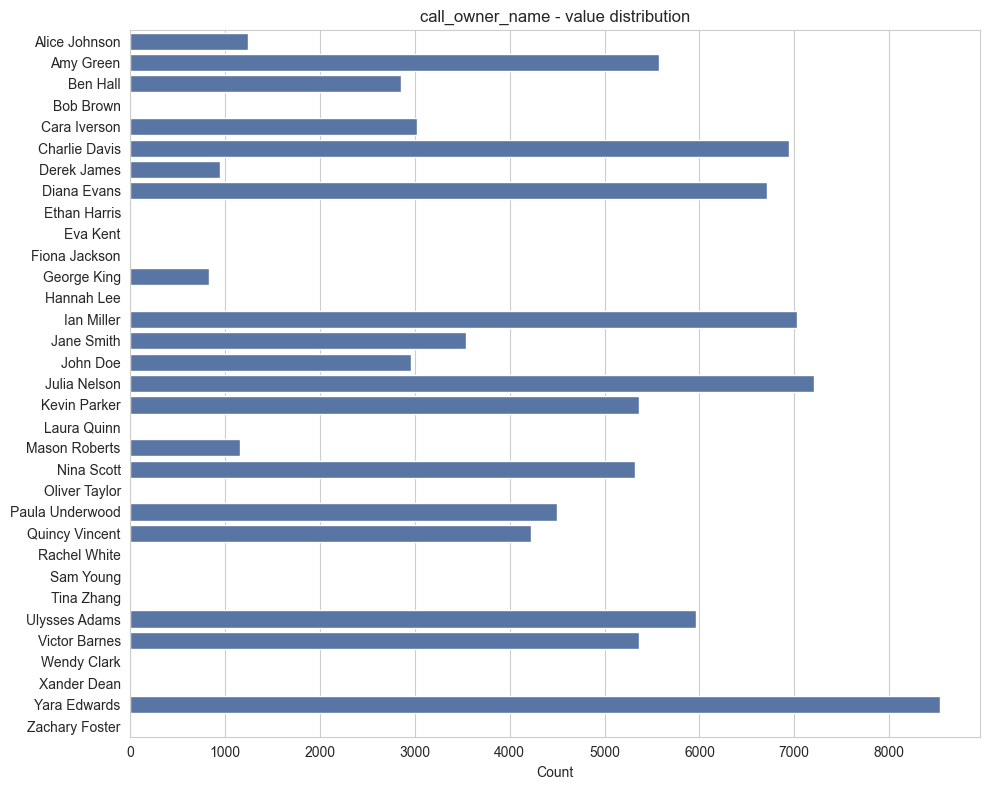


────────────────────────────────────────────────────────────
  call_type  (3 unique values)
────────────────────────────────────────────────────────────


,call_type,count,%
0,Outbound,83804,90.50
1,Missed,5742,6.20
2,Inbound,3071,3.30


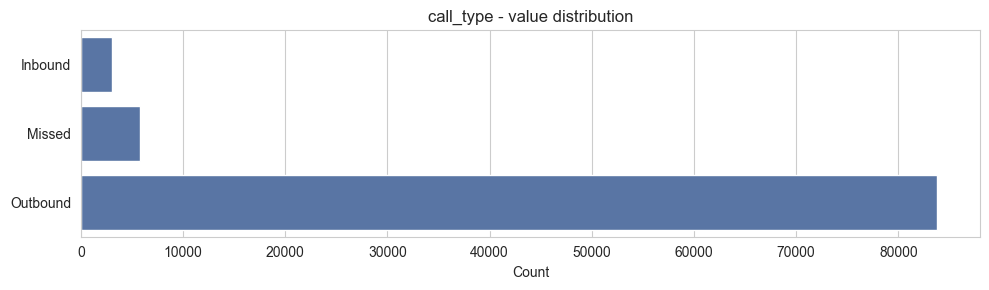


────────────────────────────────────────────────────────────
  call_status  (11 unique values)
────────────────────────────────────────────────────────────


,call_status,count,%
0,Attended Dialled,69522,75.10
1,Unattended Dialled,14146,15.30
2,Missed,5743,6.20
3,Received,3070,3.30
4,Overdue,57,0.10
5,Scheduled Attended Delay,20,0.00
6,Cancelled,19,0.00
7,Scheduled Unattended Delay,17,0.00
8,Scheduled Attended,14,0.00
9,Scheduled Unattended,6,0.00


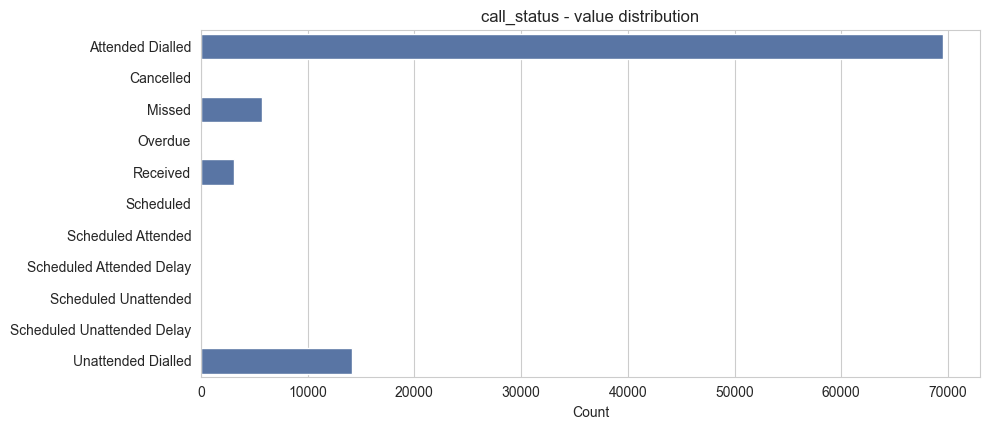

In [56]:
plt_to_save_png = ['call_owner_name', 'call_type', 'call_status']  # Specify which variable's chart to save

for col in dataset_config['cat_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}  ({df[col].nunique()} unique values)")
    print(f"{'─'*60}")

    # Frequency table
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq)

    # Bar plot (top 20 values if more)
    top_vals = freq.head(20)

    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', orient='h')
    plt.title(f"{col} - value distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    if col in plt_to_save_png:
        plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_barplot.png",
                    dpi=150, bbox_inches='tight')
    plt.show()

In [57]:
# # Move a column from cat_cols to num_cols
# col = 'column_name'

# dataset_config['cat_cols'].remove(col)
# dataset_config['num_cols'].append(col)

# print(f"num_cols: {dataset_config['num_cols']}")
# print(f"cat_cols: {dataset_config['cat_cols']}")

**Observations and decisions:**   
`call_owner_name`: 32 managers, top-10 = 65%   
`Yara Edwards` (9%) >> the call-volume leader. High concentration among the top performers    

`call_type`: Outbound 91% >> Missed 6% >> Inbound 3%   
`call_status`: Attended 75% + Unattended 15% = 90% connected   
Missed/Received = 10%, scheduling <0.1%

---
## 11. Univariate Analysis - Date Columns

For each date column:
- range and basic statistics
- monthly distribution (time series)


────────────────────────────────────────────────────────────
  call_start_time
────────────────────────────────────────────────────────────
  Min:  2023-06-30 08:43:00
  Max: 2024-06-21 15:31:00
  Missing: 0


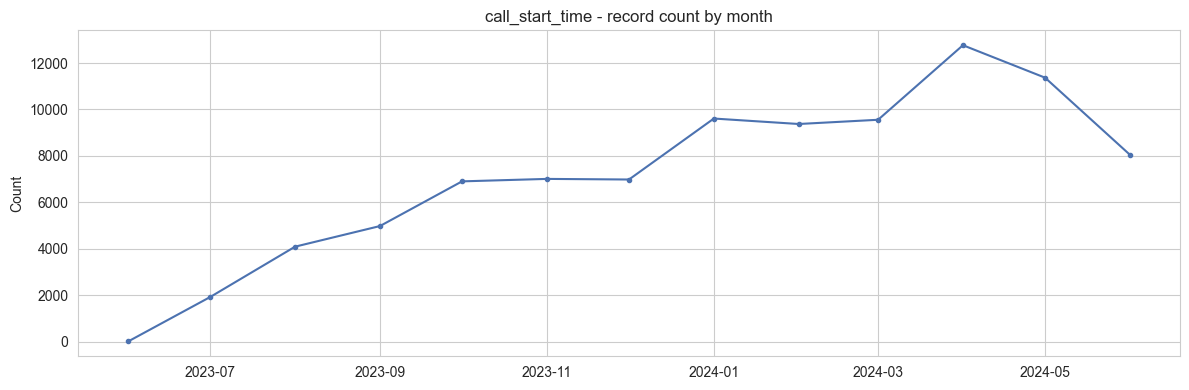

In [58]:
for col in dataset_config['date_cols']:
    if col not in df.columns:
        print(f"Column {col} not found, skipping")
        continue

    print(f"\n{'─'*60}")
    print(f"  {col}")
    print(f"{'─'*60}")

    # Basic statistics
    print(f"  Min:  {df[col].min()}")
    print(f"  Max: {df[col].max()}")
    print(f"  Missing: {df[col].isnull().sum()}")

    # Monthly time series
    monthly = df.set_index(col).resample('MS').size()

    plt.figure(figsize=(12, 4))
    plt.plot(monthly.index, monthly.values, marker='o', markersize=3, linewidth=1.5)
    plt.title(f"{col} - record count by month")
    plt.ylabel("Count")
    plt.xlabel("")
    plt.tight_layout()
    # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_timeseries.png",
    #             dpi=150, bbox_inches='tight')
    plt.show()

#### Checking Call-Date Correctness

Checking call-date correctness: `'call_start_time' <= 'created_time'` (the first call can't happen before the contact is created)

In [59]:
# 1. In the calls dataset, get the earliest call time per contact_id
calls_min = df.groupby('contact_id')['call_start_time'].min().reset_index()
calls_min.columns = ['contact_id', 'first_call_time']
# Sanity check on 3 random rows
calls_min.sample(3)

,contact_id,first_call_time
8357,5805028000032777436,2024-02-19 15:03:00
11604,5805028000043861874,2024-04-16 11:57:00
9065,5805028000035472104,2024-03-03 17:21:00


In [60]:
# 2. Load the cleaned contacts dataset contacts_cleaned.pkl
contacts = pd.read_pickle(PROCESSED / 'contacts_cleaned.pkl')
contacts.head(3)

,contact_id,contact_owner_name,created_time,modified_time,created_date
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00,2023-06-27
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00,2023-07-03
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00,2023-07-02


In [61]:
# 3. Join with contacts on 'contact_id'
check_df = calls_min.merge(contacts[['contact_id', 'created_time']], on='contact_id', how='inner')
check_df.head()

,contact_id,first_call_time,created_time
0,5805028000000645014,2023-06-30 09:20:00,2023-06-27 11:28:00
1,5805028000000872003,2023-07-05 19:19:00,2023-07-03 11:31:00
2,5805028000000939010,2023-09-13 10:58:00,2023-07-04 10:11:00
3,5805028000000942003,2023-07-06 12:00:00,2023-07-04 12:57:00
4,5805028000000961001,2023-07-06 15:48:00,2023-07-03 20:17:00


In [62]:
# 4. Check the condition: call time earlier than registration time 
check_df['call_before_contact'] = check_df['first_call_time'] < check_df['created_time']
check_df['delta_time'] = check_df['created_time'] - check_df['first_call_time']
bad_count = check_df['call_before_contact'].sum()

print(f"Calls before the contact was created: {bad_count}")
print(f"Share: {bad_count/len(check_df)*100:.2f}%")

# 5. Show the problem rows
if bad_count > 0:
    bad_calls = check_df[check_df['call_before_contact']]
    display(bad_calls.head(20))
    print(f"Problem contact_ids: {bad_calls['contact_id'].unique()[:10].tolist()}")

Calls before the contact was created: 12
Share: 0.08%


,contact_id,first_call_time,created_time,call_before_contact,delta_time
7405,5805028000028690041,2024-01-29 11:13:00,2024-01-29 11:19:00,True,0 days 00:06:00
7718,5805028000029945153,2024-02-02 20:01:00,2024-02-02 20:03:00,True,0 days 00:02:00
7836,5805028000030166308,2024-02-05 14:49:00,2024-02-05 14:56:00,True,0 days 00:07:00
7928,5805028000030660098,2024-02-07 17:21:00,2024-02-07 17:27:00,True,0 days 00:06:00
7929,5805028000030660208,2024-02-07 17:33:00,2024-02-07 17:43:00,True,0 days 00:10:00
8168,5805028000031884201,2024-02-14 10:46:00,2024-02-14 10:48:00,True,0 days 00:02:00
8361,5805028000032814930,2024-02-19 17:44:00,2024-02-19 17:57:00,True,0 days 00:13:00
8494,5805028000033289995,2024-02-22 11:19:00,2024-02-22 11:23:00,True,0 days 00:04:00
8525,5805028000033423626,2024-02-22 15:10:00,2024-02-22 15:14:00,True,0 days 00:04:00
8526,5805028000033423831,2024-02-22 15:42:00,2024-02-22 15:51:00,True,0 days 00:09:00


Problem contact_ids: ['5805028000028690041', '5805028000029945153', '5805028000030166308', '5805028000030660098', '5805028000030660208', '5805028000031884201', '5805028000032814930', '5805028000033289995', '5805028000033423626', '5805028000033423831']


**Decision**:   
since the time lag 'delta_time' is only a few minutes (only one contact has 48 min), amounting to just 0.08% of all identified mismatches => treated as a sync-timing lag in the system. Only these problem rows are updated to the 'created_time' value.

In [63]:
# 1. List the problem contacts for further processing
bad_ids = check_df.loc[check_df['call_before_contact'], 'contact_id'].unique()

print(len(bad_ids))
print(bad_ids[:10])

12
<StringArray>
['5805028000028690041', '5805028000029945153', '5805028000030166308',
 '5805028000030660098', '5805028000030660208', '5805028000031884201',
 '5805028000032814930', '5805028000033289995', '5805028000033423626',
 '5805028000033423831']
Length: 10, dtype: string


In [64]:
# 2. Build an index over contacts
contact_time_map = contacts.set_index('contact_id')['created_time']
contact_time_map.isna().sum()

# Update 'call_start_time' in df
df.loc[df['contact_id'].isin(bad_ids), 'call_start_time'] = df.loc[df['contact_id'].isin(bad_ids), 'contact_id'].map(contact_time_map)

In [65]:
# 3. In the calls dataset, get the earliest call time per contact_id again
calls_min = df.groupby('contact_id')['call_start_time'].min().reset_index()
calls_min.columns = ['contact_id', 'first_call_time']
# Sanity check on 3 random rows
calls_min.sample(3)

,contact_id,first_call_time
4653,5805028000019571270,2023-12-04 10:32:00
6779,5805028000026737101,2024-01-18 14:06:00
4482,5805028000018952597,2023-11-28 20:35:00


In [66]:
# 4. Re-check
check_df = calls_min.merge(
    contacts[['contact_id', 'created_time']],
    on='contact_id',
    how='inner'
)

check_df['call_before_contact'] = (check_df['first_call_time'] < check_df['created_time'])
print(check_df['call_before_contact'].sum())

0


In [67]:
# Repeat the date-range summary
col = 'call_start_time'
print(f"\n{'─'*60}")
print(f"  {col}")
print(f"{'─'*60}")

# Basic statistics
print(f"  Min:  {df[col].min()} - Max: {df[col].max()}")
print(f"  Missing: {df[col].isnull().sum()}")


────────────────────────────────────────────────────────────
  call_start_time
────────────────────────────────────────────────────────────
  Min:  2023-06-30 08:43:00 - Max: 2024-06-21 15:31:00
  Missing: 0


**Date observations:**

Some cases were found where the first call time slightly precedes the contact creation time (up to 48 minutes). This is interpreted as a data-sync delay. For these cases, the first call time was adjusted to match the contact creation time.

---
## 12. Univariate Analysis - Boolean Variables

For boolean variables, look at the True / False ratio.

In [68]:
# for col in dataset_config['bool_cols']:
#     if col not in df.columns:
#         print(f"Column {col} not found, skipping")
#         continue

#     print(f"\n{'─'*60}")
#     print(f"  {col}")
#     print(f"{'─'*60}")

#     # Frequency table
#     freq = df[col].value_counts().reset_index()
#     freq.columns = [col, 'count']
#     freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
#     display(freq)

#     # Pie chart
#     plt.figure(figsize=(5, 5))
#     plt.pie(freq['count'], labels=freq[col].astype(str),
#             autopct='%1.1f%%', startangle=90)
#     plt.title(f"{col}")
#     plt.tight_layout()
#     # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_pie.png",
#     #             dpi=150, bbox_inches='tight')
#     plt.show()

**Observations on boolean variables:**

The dataset has no boolean variables

---
## 13. Saving

Save the cleaned dataset to `data/processed/` as parquet.  
If a file with that name already exists, it's moved to `data/processed/backup/` with a timestamp.  
The config is updated in `data/processed/`.

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92617 entries, 0 to 92616
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   calls_id                  92617 non-null  string        
 1   call_start_time           92617 non-null  datetime64[ns]
 2   call_owner_name           92617 non-null  category      
 3   contact_id                92617 non-null  string        
 4   call_type                 92617 non-null  category      
 5   call_duration_in_seconds  92617 non-null  int64         
 6   call_status               92617 non-null  category      
 7   scheduled_in_crm          83804 non-null  float64       
 8   call_start_date           92617 non-null  datetime64[ns]
 9   status_priority           92617 non-null  float64       
 10  success_call              92617 non-null  boolean       
dtypes: boolean(1), category(3), datetime64[ns](2), float64(2), int64(1), string(2)
m

In [70]:
# Save the updated dataset to xlsx
sufix = 'cleaned'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# If the file already exists - back it up before overwriting
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Previous file -> backed up as: {backup_path.name}")

# Save the cleaned dataset
df.to_excel(dataset_path, index=False)
print(f"Dataset saved:  {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size:            {df.shape[0]:_} rows × {df.shape[1]} columns")

Dataset saved:  data\processed\calls_cleaned.xlsx
Size:            92_617 rows × 11 columns


In [71]:
# Save the updated CONFIG to pkl
sufix = 'config'
config_path = PROCESSED /  f"{sufix}_{dataset_config['name']}.pkl"

with open(config_path, "wb") as f:
    pickle.dump(dataset_config, f)
print(f"Config saved: {config_path.relative_to(PROJECT_ROOT)}")

# Save the updated DATASET to pkl
dataset_path = PROCESSED / f"{dataset_config['name']}_cleaned.pkl"    
df.to_pickle(dataset_path)

print(f"Dataset saved: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Size: {df.shape[0]:_} × {df.shape[1]}")
print(f"{'─'*60}")
print(f"ID types: { {col: df[col].dtype for col in id_cols if col in df} }")

Config saved: data\processed\config_calls.pkl
Dataset saved: data\processed\calls_cleaned.pkl
Size: 92_617 × 11
────────────────────────────────────────────────────────────
ID types: {'calls_id': string[python], 'contact_id': string[python]}


In [72]:
# Check that everything was saved
print("Contents of the processed/ folder:")
for f in sorted(PROCESSED.glob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

print()
print("Contents of the backup/ folder:")
for f in sorted(BACKUP.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Contents of the processed/ folder:
  calls_cleaned.pkl  (6768.8 KB)
  calls_cleaned.xlsx  (4887.0 KB)
  config_calls.pkl  (0.3 KB)
  config_contacts.pkl  (0.3 KB)
  contacts_cleaned.pkl  (871.5 KB)
  contacts_cleaned.xlsx  (568.0 KB)

Contents of the backup/ folder:
  calls_cleaned_20261005_0841.xlsx  (4887.0 KB)
  contacts_cleaned_20261005_0843.xlsx  (568.0 KB)


---
## 14. Final Descriptive Statistics

In [73]:
# Can be loaded from PROCESSED to confirm everything was saved correctly 
# dataset_path

In [74]:
# Load the dataset by filename

dataset_path = PROCESSED / dataset_config['data_pkl']

# Load the cleaned dataset
df = pd.read_pickle(dataset_path)

# Print info about the load result
print(f"Loaded dataset: {dataset_path.relative_to(PROJECT_ROOT)}")
print(f"Type: {type(df)} ")
print("=" * 80)
# Original dataset size:
print(df_size_prev)
df_size_old = (f"Dataset size after processing:   {df.shape[0]:_} rows × {df.shape[1]} columns")
print(df_size_old)

print("=" * 80)
df.info()
print("Checking the saved ID types:")
print(df[['calls_id', 'contact_id']].dtypes)

Loaded dataset: data\processed\calls_cleaned.pkl
Type: <class 'pandas.core.frame.DataFrame'> 
Original dataset size:   95_874 rows × 11 columns
Dataset size after processing:   92_617 rows × 11 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92617 entries, 0 to 92616
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   calls_id                  92617 non-null  string        
 1   call_start_time           92617 non-null  datetime64[ns]
 2   call_owner_name           92617 non-null  category      
 3   contact_id                92617 non-null  string        
 4   call_type                 92617 non-null  category      
 5   call_duration_in_seconds  92617 non-null  int64         
 6   call_status               92617 non-null  category      
 7   scheduled_in_crm          83804 non-null  float64       
 8   call_start_date           92617 non-null  datetime64[ns]
 9   st

In [75]:
df.describe(include='all')

,calls_id,call_start_time,call_owner_name,contact_id,call_type,call_duration_in_seconds,call_status,scheduled_in_crm,call_start_date,status_priority,success_call
count,92617,92617,92617,92617,92617,92617.00,92617,83804.00,92617,92617.00,92617
unique,92617,NaN,33,15215,3,NaN,11,NaN,NaN,NaN,2
top,5805028000000805001,NaN,Yara Edwards,Unknown,Outbound,NaN,Attended Dialled,NaN,NaN,NaN,True
freq,1,NaN,8532,3802,83804,NaN,69522,NaN,NaN,NaN,72592
mean,NaN,2024-02-04 19:01:01.536003328,NaN,NaN,NaN,170.18,NaN,0.00,2024-02-04 04:32:51.007482624,1.66,NaN
min,NaN,2023-06-30 08:43:00,NaN,NaN,NaN,0.00,NaN,0.00,2023-06-30 00:00:00,0.00,NaN
25%,NaN,2023-11-23 17:14:00,NaN,NaN,NaN,4.00,NaN,0.00,2023-11-23 00:00:00,2.00,NaN
50%,NaN,2024-02-16 15:35:00,NaN,NaN,NaN,9.00,NaN,0.00,2024-02-16 00:00:00,2.00,NaN
75%,NaN,2024-04-22 14:38:00,NaN,NaN,NaN,107.00,NaN,0.00,2024-04-22 00:00:00,2.00,NaN
max,NaN,2024-06-21 15:31:00,NaN,NaN,NaN,7625.00,NaN,1.00,2024-06-21 00:00:00,3.00,NaN


In [76]:
# Summary table for numeric columns 
h.descr_df(df)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,call_duration_in_seconds,int64,92617,0,2619,0.00,4.00,170.18,9.00,107.00,7625.00,7625.00,103.00
1,scheduled_in_crm,float64,83804,8813,2,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00
2,status_priority,float64,92617,0,4,0.00,2.00,1.66,2.00,2.00,3.00,3.00,0.00


`calls`: 93K calls, Outbound 91%, connect rate 90%   
`call_owner_name`: Yara Edwards (9%) - the call-volume leader. (33 managers), top-10 = 65%   
`call_duration`: 0-107s Short calls (median 9s), 75% <2min   
`contact_id`: 15K unique, Unknown 4K   
`sla`: 10% scheduled in CRM    
`call_status`: Attended 75%, Unattended 15%, Missed 6%

In [77]:
# Summary table for object columns 
h.descr_df(df, include=['object'], show_stats=False, show_sample_rows=True)

No columns of type ['object'] found in the dataset


In [78]:
# Summary table for object columns 
h.descr_df(df, include=['string'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,calls_id,string[python],92617,0,92617,5805028000000805001,5805028000000768006,5805028000000764027
1,contact_id,string[python],92617,0,15215,Unknown,Unknown,Unknown


In [79]:
# Summary table for category columns 
h.descr_df(df, include=['category'], show_stats=False, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,call_owner_name,category,92617,0,33,John Doe,John Doe,John Doe
1,call_type,category,92617,0,3,Inbound,Outbound,Outbound
2,call_status,category,92617,0,11,Received,Attended Dialled,Attended Dialled


In [80]:
# Summary table for bool columns 
h.descr_df(df, include=['bool'], show_stats=True, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,success_call,boolean,92617,0,2,True,True,True


In [81]:
# Summary table for datetime columns 
h.descr_df(df, include=['datetime'], show_stats=True, show_sample_rows=True)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Sample row 1,Sample row 2,Sample row 3
0,call_start_time,datetime64[ns],92617,0,68411,2023-06-30 08:43:00,2023-06-30 08:46:00,2023-06-30 08:59:00
1,call_start_date,datetime64[ns],92617,0,356,2023-06-30 00:00:00,2023-06-30 00:00:00,2023-06-30 00:00:00


In [82]:
# Date range
cols = ['call_start_time', 'call_start_date']
for col in cols:
    print(f"{'─'*80}")    
    print(f" {col}:  Min:  {df[col].min()} - Max: {df[col].max()}")
    print(f"{'─'*80}")

────────────────────────────────────────────────────────────────────────────────
 call_start_time:  Min:  2023-06-30 08:43:00 - Max: 2024-06-21 15:31:00
────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────
 call_start_date:  Min:  2023-06-30 00:00:00 - Max: 2024-06-21 00:00:00
────────────────────────────────────────────────────────────────────────────────


---
**Dataset summary:**  

### Dataset Description

|Column name  | Description |  Dtype   |  
|------------------|----------|----------|  
| **calls_id** | Call ID | string |     
| **call_start_time** | Call start time | datetime64[ns] |       
| **call_start_date** | Call start time / format='%d.%m.%Y'| datetime64[ns] |     
| **call_owner_name** | Manager who was on the call | category |       
| **contact_id** | ID of the contact the call was with | string |       
| **call_type** | Call type: | string |  category  |       
|     - Inbound - answered inbound call, |  |       
|     - Missed - missed inbound call, |  |       
|     - Outbound - outbound call |  |      
| **call_duration_in_seconds** | Call duration in seconds | int64 |        
| **call_status** | Detailed call status (many different values) | category |   |       
| **success_call** | Call-success flag | boolean |         
| **status_priority** | Call-status priority ranking  | float64 |        
| 'Received': 3, # 1st place  'Attended Dialled': 2, # 2nd place |  |        
	

**Column renaming:**   
Renamed columns (to snake_case, no parentheses or spaces).  
Renamed: id -> calls_id, contactid -> contact_id - consistent style.   

   
`Original dataset size`:   95_874 rows × 11 columns   
`Dataset size after processing`:   92_617 rows × 11 columns   
   

**Type changes:**   
1) 'scheduled_in_crm' - 2 unique values: (0, 1) -> boolean   
2) 'call_start_time' - a time field, but stored as object dtype -> datetime   

   call_start_time -> datetime   
─────────────────────────────────────────────    
Min:  2023-06-30 08:43:00 - Max: 2024-06-21 15:31:00
  Missing: 0   

4) 'dialled_number', 'tag' - columns fully empty (0 non-null) -> dropped; 'outgoing_call_status' also dropped since it fully overlaps with 'Call Status'.    
5) Categorical features converted to category. Their count meets the categorical criterion (number of unique values < the square root of the dataset size (309)), so all can be converted to 'category'.
6) 'calls_id', 'contact_id' - float64 -> int64

**Decision on missing values:**     
1) 'contact_id' - the call's unique identifier context - empty values filled with 'Unknown'.   
2) 'call_duration_in_seconds' - preliminary analysis showed these are calls that never happened, so filled with '0' seconds.   
 
**Decision on duplicates:**     

No full duplicate rows were found on the first pass. 
But found:   
Key-based iteration (`excluding id`) -> full match on the remaining fields and time (down to the second):   
    Duplicates: 3_257 
Total unique calls: 92_617   
So we kept: different call attempts or different stages of one interaction, for further analysis:  
   * Connect-rate efficiency analysis
   * How many with status 'Received' / 'Attended Dialled' -> converted into a deal
   * Manager workload (all attempts)
   * Time series across all interactions   
   
**Possible causes of duplication:**   
* Data replication: a script or integration created multiple records for the same event, especially where telephony, CRM and other sources are linked.  
* Duplication across CRM entities: the same call may appear on a deal, a contact, and other related records.   
* Webhooks/integrations: every "call ended" event -> multiple API requests -> multiple records.

**Successful calls** - 78.4% (72_592):   
Connected with duration > 0 sec + status 'Received', 'Attended Dialled' (priority: 3 and 2).

## Additional: Calls

### Filter by Duration + Status

In [83]:
# Filter by duration + status -> for calculating deal-conversion rates
# Only "useful" calls: long + successful statuses
mask_success = (
    (df['call_duration_in_seconds'] >= 30) &  # at least 30 sec
    df['call_status'].isin(['Received', 'Attended Dialled']) 
)

print(f"Useful calls: {mask_success.sum():_}")
print(f"Share: {mask_success.mean():.1%}")

df_success = df[mask_success].copy()

Useful calls: 34_392
Share: 37.1%
